# ✈️ Airline Passenger Satisfaction — Neural Network (TensorFlow/Keras)

**Bộ dữ liệu:** Airline Passenger Satisfaction (thầy cung cấp — đã chia sẵn train/test)  
**Mô hình:** `keras.Sequential` + `Dense` layers  
**Mục tiêu:** Dự đoán cột `satisfaction` (satisfied = 1, neutral or dissatisfied = 0)

---
### Quy trình thực hiện
| Bước | Nội dung |
|------|----------|
| 1 | Cài đặt & upload dữ liệu |
| 2 | Khám phá dữ liệu (EDA) |
| 3 | Xử lý missing values |
| 4 | Tiền xử lý (Encoding + Scaling) |
| 5 | Chia train → train + valid |
| 6 | Xây dựng & huấn luyện 4 mô hình |
| 7 | So sánh kết quả các mô hình |
| 8 | Đánh giá trên bộ test |


## Bước 1 — Cài đặt thư viện & Upload dữ liệu

### 1.1 — Import thư viện

In [ ]:
# Import toàn bộ thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.metrics         import (confusion_matrix, ConfusionMatrixDisplay,
                                      classification_report, accuracy_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fix seed để kết quả tái lập được
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow: {tf.__version__}')
print('Import hoàn tất!')

TensorFlow: 2.19.0
Import hoàn tất!


### 1.2 — Upload file dữ liệu

In [ ]:
# Upload 2 file: train.csv và test.csv từ máy tính
from google.colab import files

print('Chọn file train.csv và test.csv từ máy tính...')
uploaded = files.upload()
print(f'Đã upload: {list(uploaded.keys())}')

Chọn file train.csv và test.csv từ máy tính...


Saving test.csv to test.csv
Saving train.csv to train.csv
Đã upload: ['test.csv', 'train.csv']


### 1.3 — Load dữ liệu

In [ ]:
# Load 2 bộ dữ liệu riêng biệt — thầy đã chia sẵn train và test
df_train = pd.read_csv('train.csv')
df_test  = pd.read_csv('test.csv')

print('=== Train ===')
print(f'Số hàng: {df_train.shape[0]:,}  |  Số cột: {df_train.shape[1]}')
print('\n=== Test ===')
print(f'Số hàng: {df_test.shape[0]:,}  |  Số cột: {df_test.shape[1]}')
print('\n--- 3 hàng đầu bộ train ---')
df_train.head(3)

=== Train ===
Số hàng: 103,904  |  Số cột: 25

=== Test ===
Số hàng: 25,976  |  Số cột: 25

--- 3 hàng đầu bộ train ---


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied


## Bước 2 — Khám phá dữ liệu (EDA)

### 2.1 — Thông tin tổng quan

In [ ]:
# Xem kiểu dữ liệu và số lượng giá trị mỗi cột
print('=== Kiểu dữ liệu ===')
print(df_train.dtypes.to_string())
print('\n=== Thống kê mô tả ===')
df_train.describe()

=== Kiểu dữ liệu ===
Unnamed: 0                             int64
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                       

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


### 2.2 — Kiểm tra missing values

In [ ]:
# Kiểm tra các cột bị thiếu dữ liệu trong cả 2 bộ
print('=== Missing values — Train ===')
mv_train = df_train.isnull().sum()
print(mv_train[mv_train > 0])

print('\n=== Missing values — Test ===')
mv_test = df_test.isnull().sum()
print(mv_test[mv_test > 0])

=== Missing values — Train ===
Arrival Delay in Minutes    310
dtype: int64

=== Missing values — Test ===
Arrival Delay in Minutes    83
dtype: int64


### 2.3 — Phân phối nhãn mục tiêu

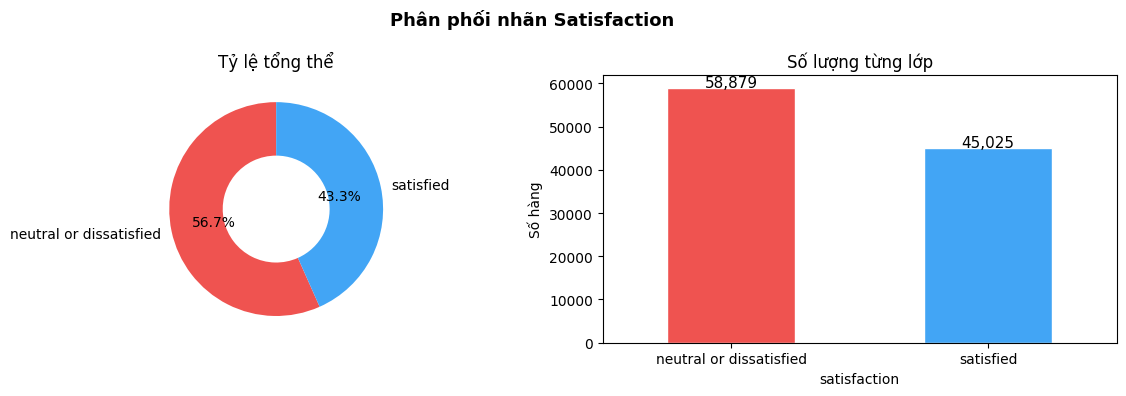

satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64


In [ ]:
# Xem tỷ lệ satisfied vs not satisfied
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Phân phối nhãn Satisfaction', fontsize=13, fontweight='bold')

# Donut chart
counts = df_train['satisfaction'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#EF5350','#42A5F5'], startangle=90,
            wedgeprops=dict(width=0.5))
axes[0].set_title('Tỷ lệ tổng thể')

# Count bar
counts.plot(kind='bar', ax=axes[1], color=['#EF5350','#42A5F5'],
            edgecolor='white', rot=0)
axes[1].set_title('Số lượng từng lớp')
axes[1].set_ylabel('Số hàng')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x()+p.get_width()/2, p.get_height()+300),
                     ha='center', fontsize=11)
plt.tight_layout()
plt.show()
print(counts)

### 2.4 — Satisfaction theo từng nhóm đối tượng

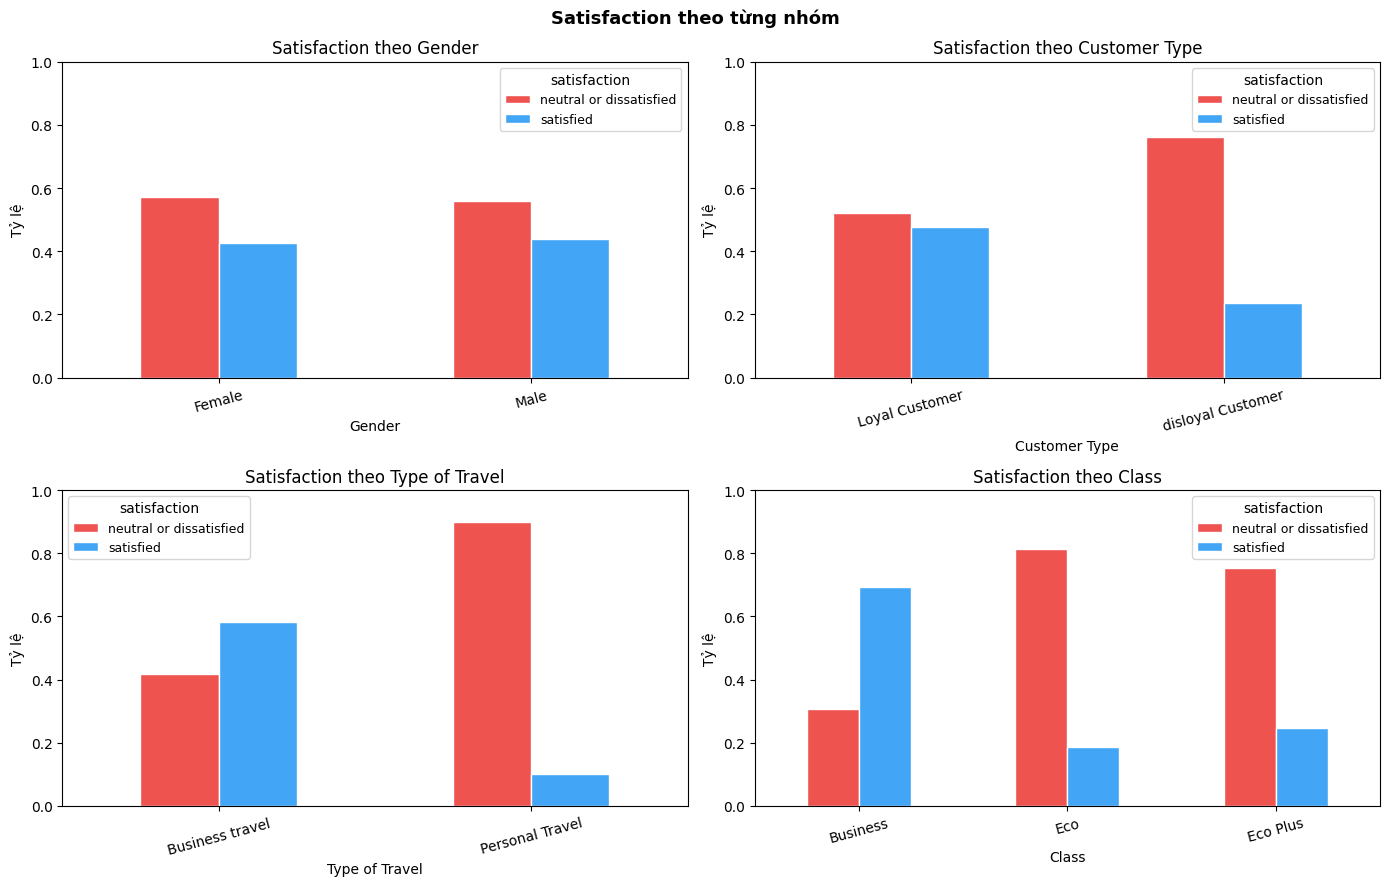

In [ ]:
# Khám phá mối liên hệ giữa các cột categorical và nhãn
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Satisfaction theo từng nhóm', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df_train.groupby(col)['satisfaction'].value_counts(normalize=True).unstack()
    ct.plot(kind='bar', ax=axes[i], color=['#EF5350','#42A5F5'],
            edgecolor='white', rot=0)
    axes[i].set_title(f'Satisfaction theo {col}')
    axes[i].set_ylabel('Tỷ lệ')
    axes[i].set_ylim(0, 1)
    axes[i].legend(title='satisfaction', fontsize=9)
    axes[i].tick_params(axis='x', labelrotation=15)

plt.tight_layout()
plt.show()

### 2.5 — Phân phối các cột điểm đánh giá dịch vụ

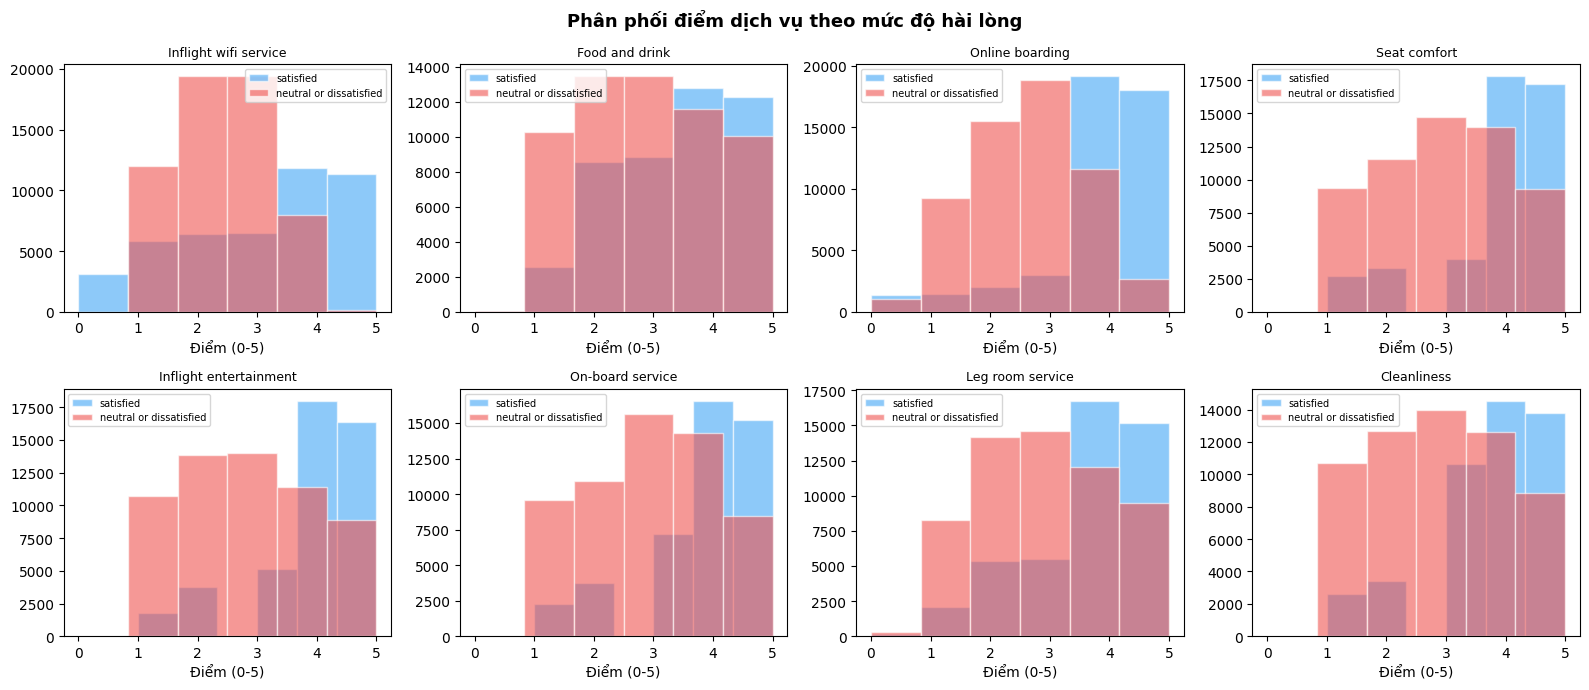

In [ ]:
# Các cột điểm dịch vụ (thang 0-5) — xem phân phối theo mức độ hài lòng
service_cols = [
    'Inflight wifi service', 'Food and drink', 'Online boarding',
    'Seat comfort', 'Inflight entertainment', 'On-board service',
    'Leg room service', 'Cleanliness'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Phân phối điểm dịch vụ theo mức độ hài lòng', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(service_cols):
    for label, color in [('satisfied','#42A5F5'),('neutral or dissatisfied','#EF5350')]:
        subset = df_train[df_train['satisfaction']==label][col]
        axes[i].hist(subset, bins=6, alpha=0.6, color=color,
                     label=label, edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Điểm (0-5)')
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

### 2.6 — Tương quan giữa các biến số (Heatmap)

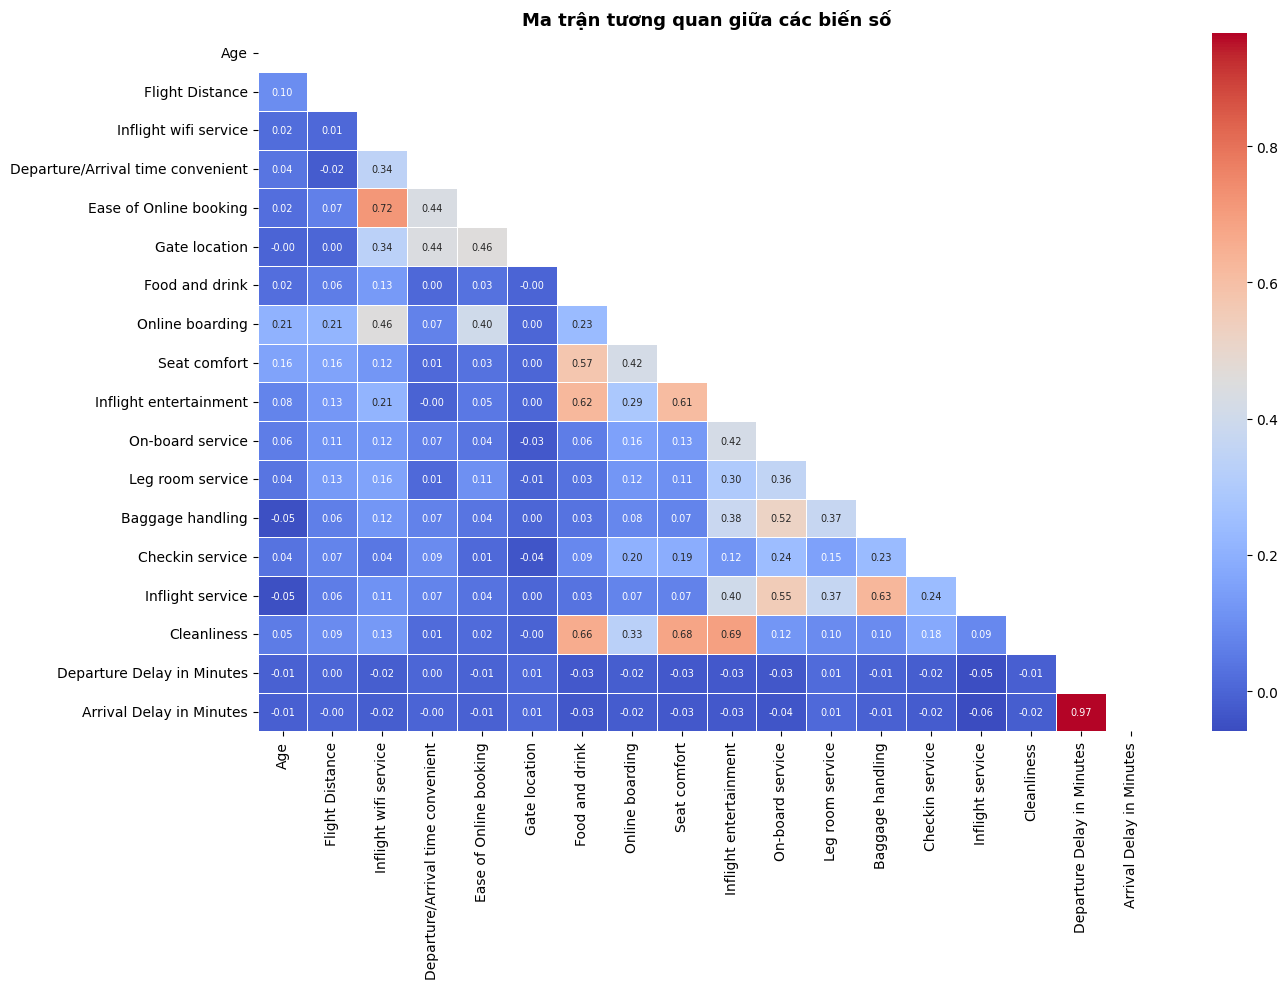

In [ ]:
# Xem ma trận tương quan để tìm quy luật ẩn giữa các cột số
num_cols = df_train.select_dtypes(include=np.number).drop(
    columns=['Unnamed: 0','id'], errors='ignore').columns

fig, ax = plt.subplots(figsize=(14, 10))
corr = df_train[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size':7})
ax.set_title('Ma trận tương quan giữa các biến số', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.7 — Phân phối Age và Flight Distance theo nhãn

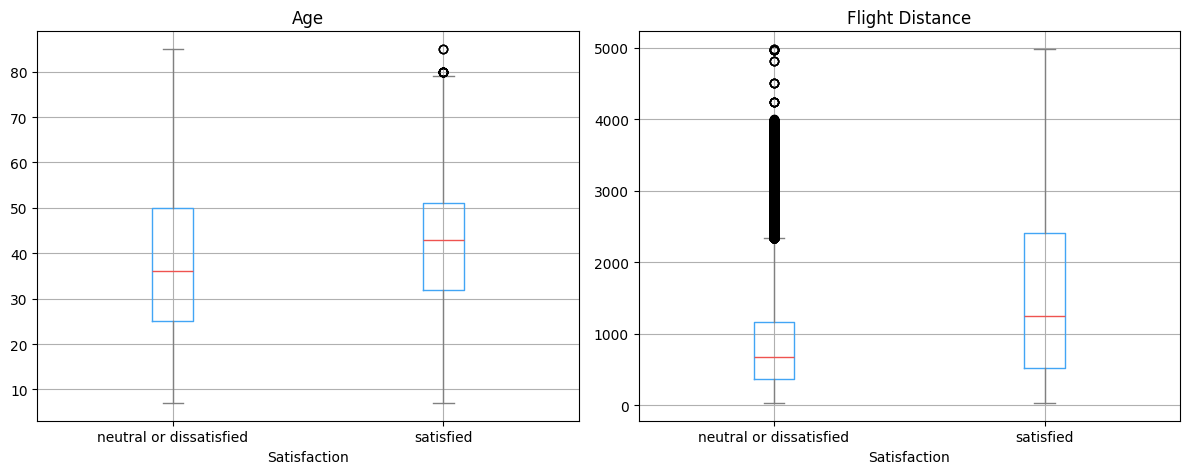

In [ ]:
# Biểu đồ boxplot: phân phối tuổi và khoảng cách bay theo mức độ hài lòng
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Phân phối biến số theo Satisfaction', fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['Age', 'Flight Distance']):
    df_train.boxplot(column=col, by='satisfaction', ax=ax,
                     color=dict(boxes='#42A5F5', whiskers='gray',
                                medians='#EF5350', caps='gray'))
    ax.set_title(col)
    ax.set_xlabel('Satisfaction')

plt.suptitle('')
plt.tight_layout()
plt.show()

## Bước 3 — Xử lý missing values

### 3.1 — Điền missing values bằng median

In [ ]:
# Cột 'Arrival Delay in Minutes' bị thiếu → điền bằng median
# Dùng median vì có outlier lớn (>1500 phút), median bền vững hơn mean

# Tính median từ TẬP TRAIN — áp dụng cho cả train lẫn test
median_delay = df_train['Arrival Delay in Minutes'].median()
print(f'Median Arrival Delay (train): {median_delay} phút')

df_train['Arrival Delay in Minutes'] = df_train['Arrival Delay in Minutes'].fillna(median_delay)
df_test['Arrival Delay in Minutes']  = df_test['Arrival Delay in Minutes'].fillna(median_delay)

print(f'Missing train còn lại: {df_train.isnull().sum().sum()}')
print(f'Missing test  còn lại: {df_test.isnull().sum().sum()}')

Median Arrival Delay (train): 0.0 phút
Missing train còn lại: 0
Missing test  còn lại: 0


## Bước 4 — Tiền xử lý dữ liệu (Encoding + Scaling)

### 4.1 — Xóa cột không cần thiết

In [ ]:
# Xóa cột index thừa và id — không có giá trị dự đoán
drop_cols = ['Unnamed: 0', 'id']
df_train.drop(columns=drop_cols, inplace=True, errors='ignore')
df_test.drop(columns=drop_cols,  inplace=True, errors='ignore')
print(f'Train: {df_train.shape}  |  Test: {df_test.shape}')

Train: (103904, 23)  |  Test: (25976, 23)


### 4.2 — Encode nhãn mục tiêu

In [ ]:
# Encode cột target: satisfied=1, neutral or dissatisfied=0
le_target = LabelEncoder()
df_train['satisfaction'] = le_target.fit_transform(df_train['satisfaction'])
df_test['satisfaction']  = le_target.transform(df_test['satisfaction'])

print(f'Mapping: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')

Mapping: {'neutral or dissatisfied': np.int64(0), 'satisfied': np.int64(1)}


*văn bản in nghiêng*### 4.3 — Encode các cột categorical

In [ ]:
# Label Encoding cho cột nhị phân (2 giá trị)
binary_cols = ['Gender', 'Customer Type', 'Type of Travel']
for col in binary_cols:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])
    df_test[col]  = le.transform(df_test[col])
    print(f'  {col}: {list(le.classes_)} → [0, 1]')

# One-Hot Encoding cho 'Class' (3 giá trị: Business / Eco / Eco Plus)
df_train = pd.get_dummies(df_train, columns=['Class'], dtype=int)
df_test  = pd.get_dummies(df_test,  columns=['Class'], dtype=int)

# Đảm bảo 2 bộ có cùng cột sau one-hot
df_train, df_test = df_train.align(df_test, join='left', axis=1, fill_value=0)
print(f'\nShape sau encode — Train: {df_train.shape}  |  Test: {df_test.shape}')

  Gender: ['Female', 'Male'] → [0, 1]
  Customer Type: ['Loyal Customer', 'disloyal Customer'] → [0, 1]
  Type of Travel: ['Business travel', 'Personal Travel'] → [0, 1]

Shape sau encode — Train: (103904, 25)  |  Test: (25976, 25)


In [ ]:
df_train.head(3)

NameError: name 'df_train' is not defined

### 4.4 — Tách X và y

In [ ]:
# Tách features (X) và nhãn (y)
X_all   = df_train.drop(columns=['satisfaction'])
y_all   = df_train['satisfaction']
X_test  = df_test.drop(columns=['satisfaction'])
y_test  = df_test['satisfaction']

print(f'X_all  : {X_all.shape}')
print(f'y_all  : {y_all.shape}')
print(f'X_test : {X_test.shape}')
print(f'\nSố features (= số neurons lớp đầu tiên): {X_all.shape[1]}')
print(f'Danh sách features:\n{list(X_all.columns)}')

X_all  : (103904, 24)
y_all  : (103904,)
X_test : (25976, 24)

Số features (= số neurons lớp đầu tiên): 24
Danh sách features:
['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Class_Business', 'Class_Eco', 'Class_Eco Plus']


## Bước 5 — Chia bộ train thành train + valid (80/20)

### 5.1 — Split và Scale

In [ ]:
# Chia bộ train thành train (80%) và valid (20%)
# Bộ test giữ nguyên — chỉ dùng để đánh giá cuối cùng
X_train, X_valid, y_train, y_valid = train_test_split(
    X_all, y_all,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y_all  # giữ tỷ lệ lớp giống nhau
)

print(f'X_train : {X_train.shape}')
print(f'X_valid : {X_valid.shape}')
print(f'X_test  : {X_test.shape}')

X_train : (83123, 24)
X_valid : (20781, 24)
X_test  : (25976, 24)


### 5.2 — Chuẩn hóa dữ liệu (StandardScaler)

In [ ]:
# Chuẩn hóa: fit chỉ trên X_train, áp dụng lên valid và test
# Tránh data leakage (không được fit trên valid/test)
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)   # fit + transform
X_valid_sc = scaler.transform(X_valid)        # chỉ transform
X_test_sc  = scaler.transform(X_test)         # chỉ transform

n_features = X_train_sc.shape[1]
print(f'Số cột sau khi scale (= lớp Dense đầu tiên): {n_features}')

Số cột sau khi scale (= lớp Dense đầu tiên): 24


## Bước 6 — Xây dựng và huấn luyện 4 mô hình

Mỗi mô hình dùng một optimizer khác nhau: `adam`, `adagrad`, `adadelta`, `adamax`  
Kiến trúc chung: `Dense(24) → Dense(16) → Dense(8) → Dense(1)`  
Activation thay phiên: `relu` và `sigmoid`


### Mô hình 1 — Optimizer: `adam` | Activation: `relu` xen kẽ `sigmoid`
> Đặt tên: `model_v1_adam`

In [ ]:
# Mô hình 1: optimizer=adam, xen kẽ relu và sigmoid
# Lớp đầu: neurons = số cột sau scale (24)
# Lớp cuối: 1 neuron + sigmoid (phân loại nhị phân)
model_v1_adam = keras.Sequential([
    layers.Dense(24, activation='relu'),     # lớp 1: 24 neurons (= số features)
    layers.Dense(16, activation='sigmoid'),  # lớp 2: giảm xuống 16
    layers.Dense(8,  activation='relu'),     # lớp 3: giảm xuống 8
    layers.Dense(1,  activation='sigmoid'),  # lớp output: 1 neuron
], name='model_v1_adam')

model_v1_adam.compile(
    loss      = 'binary_crossentropy',
    optimizer = 'adam',
    metrics   = ['accuracy']
)

model_v1_adam.summary()

Model: "model_v1_adam"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### Huấn luyện model_v1_adam

In [ ]:
# Huấn luyện model_v1_adam trên X_train, kiểm tra trên X_valid
history_v1 = model_v1_adam.fit(
    X_train_sc, y_train,
    validation_data = (X_valid_sc, y_valid),
    epochs          = 50,
    batch_size      = 256,
    verbose         = 1
)

val_acc_v1 = max(history_v1.history['val_accuracy'])
print(f'\nmodel_v1_adam — Best Val Accuracy: {val_acc_v1*100:.2f}%')

Epoch 1/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8267 - loss: 0.5578 - val_accuracy: 0.8906 - val_loss: 0.4424
Epoch 2/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9004 - loss: 0.3947 - val_accuracy: 0.9109 - val_loss: 0.3513
Epoch 3/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9167 - loss: 0.3233 - val_accuracy: 0.9225 - val_loss: 0.2966
Epoch 4/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9261 - loss: 0.2770 - val_accuracy: 0.9294 - val_loss: 0.2598
Epoch 5/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9331 - loss: 0.2440 - val_accuracy: 0.9343 - val_loss: 0.2321
Epoch 6/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9381 - loss: 0.2197 - val_accuracy: 0.9393 - val_loss: 0.2103
Epoch 7/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9416 - loss: 0.2011 - val_accuracy: 0.9415 - val_loss: 0.1940
Epoch 8/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9437 - loss: 0.1862 - val_accuracy: 0

### Mô hình 2 — Optimizer: `adagrad` | Activation: `relu`
> Đặt tên: `model_v2_adagrad`

In [ ]:
# Mô hình 2: optimizer=adagrad, toàn bộ dùng relu
model_v2_adagrad = keras.Sequential([
    layers.Dense(24, activation='relu'),  # lớp 1: 24 neurons
    layers.Dense(16, activation='relu'),  # lớp 2: giảm xuống 16
    layers.Dense(8,  activation='relu'),  # lớp 3: giảm xuống 8
    layers.Dense(1,  activation='sigmoid'),  # lớp output
], name='model_v2_adagrad')

model_v2_adagrad.compile(
    loss      = 'binary_crossentropy',
    optimizer = 'adagrad',
    metrics   = ['accuracy']
)

model_v2_adagrad.summary()

Model: "model_v2_adagrad"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### Huấn luyện model_v2_adagrad

In [ ]:
# Huấn luyện model_v2_adagrad
history_v2 = model_v2_adagrad.fit(
    X_train_sc, y_train,
    validation_data = (X_valid_sc, y_valid),
    epochs          = 50,
    batch_size      = 256,
    verbose         = 1
)

val_acc_v2 = max(history_v2.history['val_accuracy'])
print(f'\nmodel_v2_adagrad — Best Val Accuracy: {val_acc_v2*100:.2f}%')

Epoch 1/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4422 - loss: 0.7353 - val_accuracy: 0.4693 - val_loss: 0.7103
Epoch 2/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5203 - loss: 0.6964 - val_accuracy: 0.5707 - val_loss: 0.6835
Epoch 3/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6187 - loss: 0.6725 - val_accuracy: 0.6575 - val_loss: 0.6600
Epoch 4/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6940 - loss: 0.6484 - val_accuracy: 0.7166 - val_loss: 0.6343
Epoch 5/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7410 - loss: 0.6211 - val_accuracy: 0.7551 - val_loss: 0.6050
Epoch 6/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7738 - loss: 0.5903 - val_accuracy: 0.7855 - val_loss: 0.5724
Epoch 7/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7977 - loss: 0.5570 - val_accuracy: 0.8067 - val_loss: 0.5382
Epoch 8/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8156 - loss: 0.5232 - val_accuracy: 0.

### Mô hình 3 — Optimizer: `adadelta` | Activation: `sigmoid`
> Đặt tên: `model_v3_adadelta`

In [ ]:
# Mô hình 3: optimizer=adadelta, toàn bộ dùng sigmoid
model_v3_adadelta = keras.Sequential([
    layers.Dense(24, activation='sigmoid'),  # lớp 1: 24 neurons
    layers.Dense(16, activation='sigmoid'),  # lớp 2: giảm xuống 16
    layers.Dense(8,  activation='sigmoid'),  # lớp 3: giảm xuống 8
    layers.Dense(1,  activation='sigmoid'),  # lớp output
], name='model_v3_adadelta')

model_v3_adadelta.compile(
    loss      = 'binary_crossentropy',
    optimizer = 'adadelta',
    metrics   = ['accuracy']
)

model_v3_adadelta.summary()

Model: "model_v3_adadelta"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### Huấn luyện model_v3_adadelta

In [ ]:
# Huấn luyện model_v3_adadelta
history_v3 = model_v3_adadelta.fit(
    X_train_sc, y_train,
    validation_data = (X_valid_sc, y_valid),
    epochs          = 50,
    batch_size      = 256,
    verbose         = 1
)

val_acc_v3 = max(history_v3.history['val_accuracy'])
print(f'\nmodel_v3_adadelta — Best Val Accuracy: {val_acc_v3*100:.2f}%')

Epoch 1/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5667 - loss: 0.6899 - val_accuracy: 0.5667 - val_loss: 0.6897
Epoch 2/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5667 - loss: 0.6896 - val_accuracy: 0.5667 - val_loss: 0.6894
Epoch 3/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5667 - loss: 0.6893 - val_accuracy: 0.5667 - val_loss: 0.6891
Epoch 4/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5667 - loss: 0.6890 - val_accuracy: 0.5667 - val_loss: 0.6888
Epoch 5/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5667 - loss: 0.6887 - val_accuracy: 0.5667 - val_loss: 0.6885
Epoch 6/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5667 - loss: 0.6884 - val_accuracy: 0.5667 - val_loss: 0.6883
Epoch 7/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5667 - loss: 0.6881 - val_accuracy: 0.5667 - val_loss: 0.6880
Epoch 8/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5667 - loss: 0.6878 - val_accuracy: 0.

### Mô hình 4 — Optimizer: `adamax` | Activation: `sigmoid` xen kẽ `relu`
> Đặt tên: `model_v4_adamax`

In [ ]:
# Mô hình 4: optimizer=adamax, xen kẽ sigmoid và relu (thứ tự đảo)
model_v4_adamax = keras.Sequential([
    layers.Dense(24, activation='sigmoid'),  # lớp 1: 24 neurons
    layers.Dense(16, activation='relu'),     # lớp 2: giảm xuống 16
    layers.Dense(8,  activation='sigmoid'),  # lớp 3: giảm xuống 8
    layers.Dense(1,  activation='sigmoid'),  # lớp output
], name='model_v4_adamax')

model_v4_adamax.compile(
    loss      = 'binary_crossentropy',
    optimizer = 'adamax',
    metrics   = ['accuracy']
)

model_v4_adamax.summary()

Model: "model_v4_adamax"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### Huấn luyện model_v4_adamax

In [ ]:
# Huấn luyện model_v4_adamax
history_v4 = model_v4_adamax.fit(
    X_train_sc, y_train,
    validation_data = (X_valid_sc, y_valid),
    epochs          = 50,
    batch_size      = 256,
    verbose         = 1
)

val_acc_v4 = max(history_v4.history['val_accuracy'])
print(f'\nmodel_v4_adamax — Best Val Accuracy: {val_acc_v4*100:.2f}%')

Epoch 1/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7810 - loss: 0.5345 - val_accuracy: 0.8549 - val_loss: 0.4236
Epoch 2/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8649 - loss: 0.3770 - val_accuracy: 0.8712 - val_loss: 0.3451
Epoch 3/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8758 - loss: 0.3328 - val_accuracy: 0.8763 - val_loss: 0.3240
Epoch 4/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8783 - loss: 0.3207 - val_accuracy: 0.8780 - val_loss: 0.3162
Epoch 5/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8787 - loss: 0.3152 - val_accuracy: 0.8789 - val_loss: 0.3115
Epoch 6/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8794 - loss: 0.3113 - val_accuracy: 0.8796 - val_loss: 0.3077
Epoch 7/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8802 - loss: 0.3080 - val_accuracy: 0.8801 - val_loss: 0.3043
Epoch 8/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8812 - loss: 0.3045 - val_accuracy: 0.

## Bước 7 — So sánh kết quả các mô hình

### 7.1 — Biểu đồ Accuracy & Loss của 4 mô hình

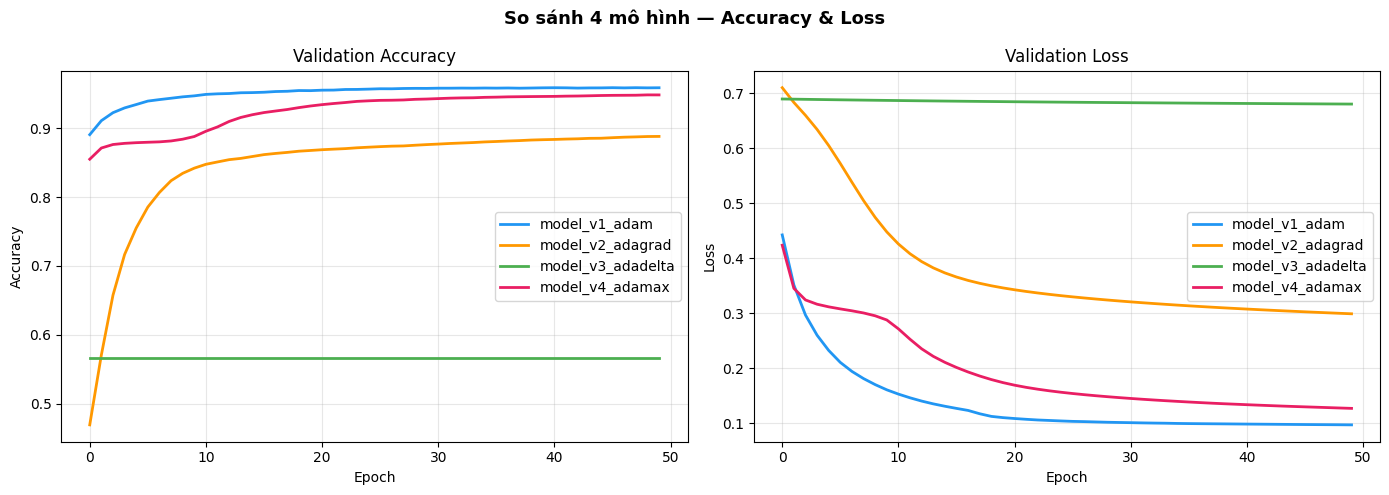

In [ ]:
# Vẽ đường accuracy và loss của cả 4 mô hình để so sánh
histories = {
    'model_v1_adam'     : history_v1,
    'model_v2_adagrad'  : history_v2,
    'model_v3_adadelta' : history_v3,
    'model_v4_adamax'   : history_v4,
}
colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('So sánh 4 mô hình — Accuracy & Loss', fontsize=13, fontweight='bold')

for (name, hist), color in zip(histories.items(), colors):
    axes[0].plot(hist.history['val_accuracy'], label=name, color=color, linewidth=2)
    axes[1].plot(hist.history['val_loss'],     label=name, color=color, linewidth=2)

axes[0].set_title('Validation Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7.2 — Bảng tổng kết so sánh

In [ ]:
# Bảng so sánh validation accuracy của 4 mô hình
summary = {
    'Mô hình'   : ['model_v1_adam','model_v2_adagrad','model_v3_adadelta','model_v4_adamax'],
    'Optimizer' : ['adam','adagrad','adadelta','adamax'],
    'Activation': ['relu+sigmoid','relu','sigmoid','sigmoid+relu'],
    'Best Val Accuracy': [
        f'{max(history_v1.history["val_accuracy"])*100:.2f}%',
        f'{max(history_v2.history["val_accuracy"])*100:.2f}%',
        f'{max(history_v3.history["val_accuracy"])*100:.2f}%',
        f'{max(history_v4.history["val_accuracy"])*100:.2f}%',
    ]
}

df_summary = pd.DataFrame(summary)
print('=== Bảng so sánh 4 mô hình ===')
print(df_summary.to_string(index=False))

=== Bảng so sánh 4 mô hình ===
          Mô hình Optimizer   Activation Best Val Accuracy
    model_v1_adam      adam relu+sigmoid            95.88%
 model_v2_adagrad   adagrad         relu            88.80%
model_v3_adadelta  adadelta      sigmoid            56.67%
  model_v4_adamax    adamax sigmoid+relu            94.83%


## Bước 8 — Đánh giá mô hình tốt nhất trên bộ test

### 8.1 — Chọn mô hình tốt nhất và đánh giá

In [ ]:
# Chọn mô hình có val_accuracy cao nhất để test
best_scores = {
    'model_v1_adam'     : max(history_v1.history['val_accuracy']),
    'model_v2_adagrad'  : max(history_v2.history['val_accuracy']),
    'model_v3_adadelta' : max(history_v3.history['val_accuracy']),
    'model_v4_adamax'   : max(history_v4.history['val_accuracy']),
}
best_name = max(best_scores, key=best_scores.get)
best_models = {
    'model_v1_adam'     : model_v1_adam,
    'model_v2_adagrad'  : model_v2_adagrad,
    'model_v3_adadelta' : model_v3_adadelta,
    'model_v4_adamax'   : model_v4_adamax,
}
best_model = best_models[best_name]
print(f'Mô hình tốt nhất: {best_name} (Val Acc = {best_scores[best_name]*100:.2f}%)')

# Đánh giá trên bộ test
test_loss, test_acc = best_model.evaluate(X_test_sc, y_test, verbose=0)
print(f'\nTest Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

Mô hình tốt nhất: model_v1_adam (Val Acc = 95.88%)

Test Accuracy : 95.84%
Test Loss     : 0.1020


### 8.2 — Classification Report & Confusion Matrix

812/812 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
=== Classification Report ===
                         precision    recall  f1-score   support

neutral or dissatisfied       0.95      0.97      0.96     14573
              satisfied       0.97      0.94      0.95     11403

               accuracy                           0.96     25976
              macro avg       0.96      0.96      0.96     25976
           weighted avg       0.96      0.96      0.96     25976



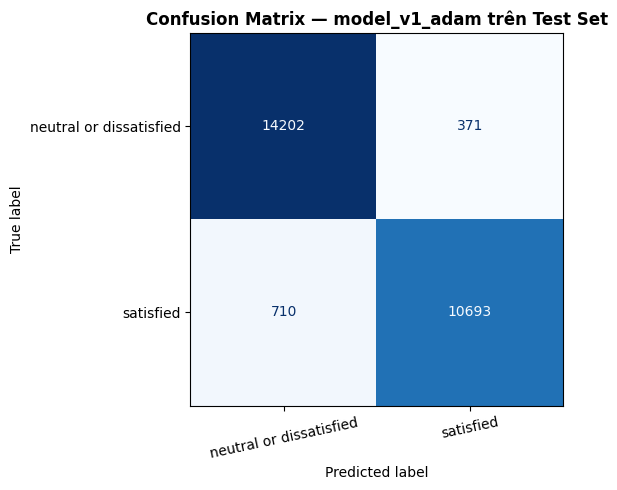

In [ ]:
# Dự đoán nhãn trên bộ test
y_pred_prob = best_model.predict(X_test_sc).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le_target.classes_).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name} trên Test Set',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', labelrotation=12)
plt.tight_layout()
plt.show()

### 8.3 — Đánh giá tất cả mô hình trên test set

In [ ]:
# So sánh test accuracy của tất cả 4 mô hình
print('=== Test Accuracy — Tất cả mô hình ===')
for name, mdl in best_models.items():
    _, acc = mdl.evaluate(X_test_sc, y_test, verbose=0)
    print(f'  {name:<25s}: {acc*100:.2f}%')

=== Test Accuracy — Tất cả mô hình ===
  model_v1_adam            : 95.84%
  model_v2_adagrad         : 88.20%
  model_v3_adadelta        : 56.10%
  model_v4_adamax          : 94.98%
